# IMPORT LIBRARIES

In [33]:
# PLOTTING & DATA STUFF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import joblib

# NN
from sklearn.linear_model import Perceptron
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import kerastuner as kt

# ML GENERAL
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder


# IMBAL LEARNING
from imblearn.over_sampling import SMOTE


# HELPERS
from utils import backup_dataframe, load_latest_backup


# LOAD CSV

In [44]:
pd.set_option("display.max_colwidth", None)  # Show full content in columns
pd.set_option("display.max_rows", None)

In [45]:
df = pd.read_csv("dataset/train_post_outlier.csv")

# FAST CHECK AND PROCESS

In [46]:
df.shape

(115367, 67)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115367 entries, 0 to 115366
Data columns (total 67 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   115367 non-null  int64  
 1   runtimeMinutes               115367 non-null  float64
 2   awardWins                    115367 non-null  float64
 3   numVotes                     115367 non-null  float64
 4   awardNominationsExcludeWins  115367 non-null  float64
 5   canHaveEpisodes              115367 non-null  int64  
 6   isAdult                      115367 non-null  int64  
 7   numRegions                   115367 non-null  float64
 8   userReviewsTotal             115367 non-null  float64
 9   countryOfOrigin              115367 non-null  object 
 10  genres                       115367 non-null  object 
 11  castNumber                   115367 non-null  float64
 12  companiesNumber              115367 non-null  float64
 13 

In [48]:
df = df.drop(columns="Unnamed: 0")

In [49]:
cols_to_drop = [
    "countryOfOrigin",
    "genres",
    "soundMixes",
    "continent",
    "filtered_genres",
    "filtered_soundMixes",
]
df = df.drop(columns=cols_to_drop)

In [50]:
df.columns.to_list()

['runtimeMinutes',
 'awardWins',
 'numVotes',
 'awardNominationsExcludeWins',
 'canHaveEpisodes',
 'isAdult',
 'numRegions',
 'userReviewsTotal',
 'castNumber',
 'companiesNumber',
 'averageRating',
 'externalLinks',
 'writerCredits',
 'directorsCredits',
 'quotesTotal',
 'release_decade',
 'num_genres',
 'has_awards',
 'word_count',
 'num_countries',
 'award_ratio',
 'total_multimedia',
 'rating_category',
 'sentiment_Negative',
 'sentiment_Neutral',
 'sentiment_Positive',
 'titleType_movie',
 'titleType_short',
 'titleType_tvEpisode',
 'titleType_tvMiniSeries',
 'titleType_tvMovie',
 'titleType_tvSeries',
 'titleType_tvShort',
 'titleType_tvSpecial',
 'titleType_video',
 'titleType_videoGame',
 'continent_Africa',
 'continent_Asia',
 'continent_Europe',
 'continent_North America',
 'continent_Oceania',
 'continent_Other',
 'continent_South America',
 'genre_Action',
 'genre_Adventure',
 'genre_Animation',
 'genre_Comedy',
 'genre_Crime',
 'genre_Documentary',
 'genre_Drama',
 'genre_

# SPLIT

In [51]:
X = df.drop(columns=["rating_category", "averageRating"])
y = df["rating_category"]


In [52]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115367 entries, 0 to 115366
Data columns (total 58 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   runtimeMinutes               115367 non-null  float64
 1   awardWins                    115367 non-null  float64
 2   numVotes                     115367 non-null  float64
 3   awardNominationsExcludeWins  115367 non-null  float64
 4   canHaveEpisodes              115367 non-null  int64  
 5   isAdult                      115367 non-null  int64  
 6   numRegions                   115367 non-null  float64
 7   userReviewsTotal             115367 non-null  float64
 8   castNumber                   115367 non-null  float64
 9   companiesNumber              115367 non-null  float64
 10  externalLinks                115367 non-null  float64
 11  writerCredits                115367 non-null  float64
 12  directorsCredits             115367 non-null  float64
 13 

In [53]:
y.value_counts()

rating_category
High         25519
Low          23713
Very Low     23700
Medium       22526
Very High    19909
Name: count, dtype: int64

In [54]:
# encoding target
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [56]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(92293, 58) (23074, 58) (92293,) (23074,)


# PERCEPTRON

In [57]:
# Inizializza il Perceptron
perceptron = Perceptron(random_state=42)

# Fit sui dati
perceptron.fit(X_train, y_train)


Perceptron(random_state=42)

In [58]:
y_pred_perceptron = perceptron.predict(X_test)

/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [59]:
print("=== Perceptron Report ===")
print(classification_report(y_test, y_pred_perceptron))

=== Perceptron Report ===
              precision    recall  f1-score   support

           0       0.27      0.17      0.21      5104
           1       0.24      0.16      0.19      4743
           2       0.22      0.19      0.21      4505
           3       0.20      0.31      0.24      3982
           4       0.35      0.51      0.42      4740

    accuracy                           0.27     23074
   macro avg       0.26      0.27      0.25     23074
weighted avg       0.26      0.27      0.25     23074



# MLP

In [27]:
#!pip install tensorflow

In [60]:
X_train.shape[1]

58

## SIMPLE NN 61-120-7 
OPT: ADAM <BR>
BATCH: 32 <BR>
REG: NO <BR>
MOM: NO <BR>
EARLY STOPPING: NO <BR>

In [61]:
# 1. Definiamo la rete di base
model = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),  # Input layer
        layers.Dense(120, activation="relu"),  # 1 hidden layer
        layers.Dense(len(np.unique(y_train)), activation="softmax"),  # Output layer
    ]
)

# 2. Compila il modello§
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# 3. Allena il modello
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,  # userà 20% dei dati per validation interna
    epochs=50,
    batch_size=32,
    verbose=2,
)

# 4. Valutazione su Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 5. Predizioni
y_pred_prob = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# 6. Report di classificazione
print("=== MLP Keras Report ===")
print(classification_report(y_test, y_pred_classes))


Epoch 1/50
2308/2308 - 1s - 552us/step - accuracy: 0.3480 - loss: 1.4747 - val_accuracy: 0.3678 - val_loss: 1.4386
Epoch 2/50
2308/2308 - 1s - 407us/step - accuracy: 0.3746 - loss: 1.4219 - val_accuracy: 0.3736 - val_loss: 1.4143
Epoch 3/50
2308/2308 - 1s - 396us/step - accuracy: 0.3833 - loss: 1.3996 - val_accuracy: 0.3847 - val_loss: 1.3999
Epoch 4/50
2308/2308 - 1s - 386us/step - accuracy: 0.3889 - loss: 1.3877 - val_accuracy: 0.3798 - val_loss: 1.4028
Epoch 5/50
2308/2308 - 1s - 384us/step - accuracy: 0.3934 - loss: 1.3774 - val_accuracy: 0.3859 - val_loss: 1.3928
Epoch 6/50
2308/2308 - 1s - 414us/step - accuracy: 0.3979 - loss: 1.3704 - val_accuracy: 0.3904 - val_loss: 1.3842
Epoch 7/50
2308/2308 - 1s - 412us/step - accuracy: 0.4015 - loss: 1.3630 - val_accuracy: 0.3901 - val_loss: 1.3901
Epoch 8/50
2308/2308 - 1s - 491us/step - accuracy: 0.4045 - loss: 1.3583 - val_accuracy: 0.3959 - val_loss: 1.3766
Epoch 9/50
2308/2308 - 1s - 391us/step - accuracy: 0.4068 - loss: 1.3539 - val_a

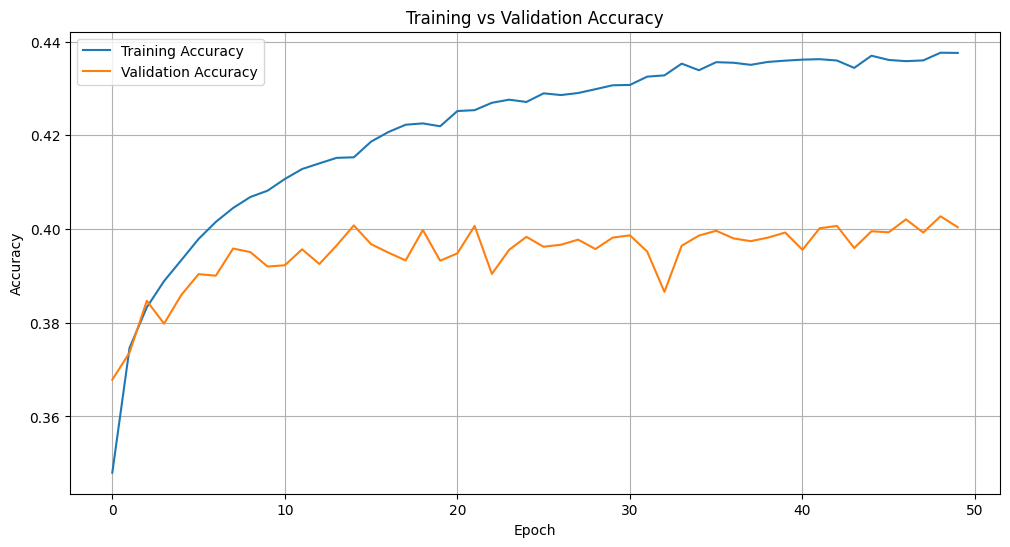

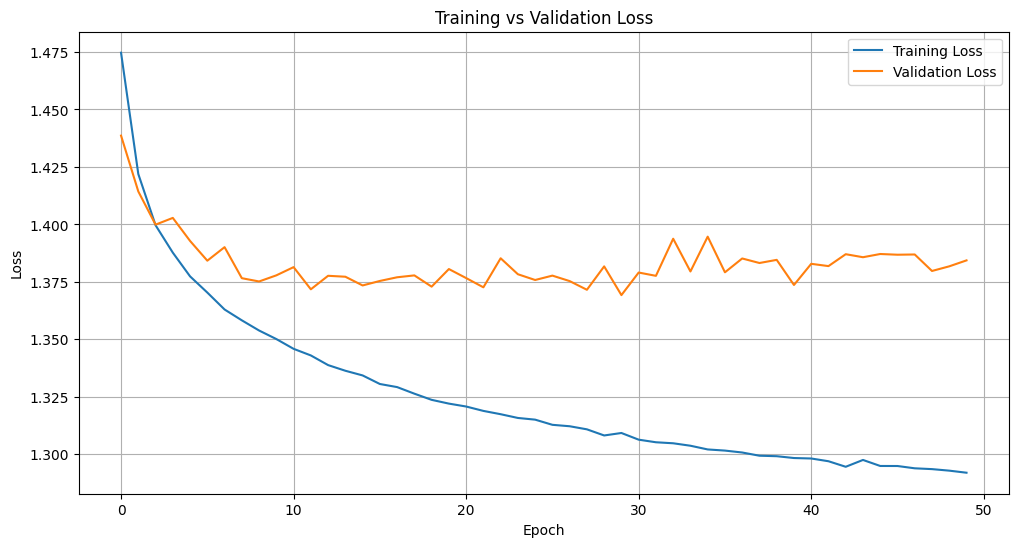

In [64]:
# 1. Plot Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot Loss (facoltativo ma utile)
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## GRID SEARCH

In [52]:
#!pip install keras-tuner -q



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [65]:
def model_builder(hp):
    inputs = keras.Input(shape=(X_train.shape[1],))
    x = inputs

    # 1) Numero di layer e unità per layer
    num_layers = hp.Int("num_layers", 1, 3, default=2)
    for i in range(num_layers):
        units = hp.Choice(f"units_{i}", [64, 128, 256], default=128)

        # 2) Regolarizzazione L1/L2
        reg_type = hp.Choice(f"reg_type_{i}", ["none", "l1", "l2"], default="none")
        if reg_type == "l1":
            reg = keras.regularizers.l1(hp.Float(f"l1_{i}", 1e-5, 1e-2, sampling="LOG"))
        elif reg_type == "l2":
            reg = keras.regularizers.l2(hp.Float(f"l2_{i}", 1e-5, 1e-2, sampling="LOG"))
        else:
            reg = None

        x = layers.Dense(units, activation="relu", kernel_regularizer=reg)(x)

        # 3) Dropout
        dropout_rate = hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1, default=0.0)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

        # 4) BatchNorm (sempre opzionale)
        if hp.Boolean(f"batchnorm_{i}", default=True):
            x = layers.BatchNormalization()(x)

    outputs = layers.Dense(len(np.unique(y_train)), activation="softmax")(x)
    model = keras.Model(inputs, outputs)

    # 5) Scelta dell'ottimizzatore e dei suoi iperparametri
    optimizer_choice = hp.Choice("optimizer", ["sgd", "adam"], default="adam")
    if optimizer_choice == "sgd":
        # momentum
        momentum = hp.Float("momentum", 0.0, 0.99, step=0.1, default=0.9)
        lr = hp.Float("sgd_lr", 1e-4, 1e-2, sampling="LOG", default=1e-3)
        optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    else:
        # Adam con beta1 come “momentum”
        beta1 = hp.Float("beta1", 0.8, 0.99, step=0.05, default=0.9)
        lr = hp.Float("adam_lr", 1e-5, 1e-2, sampling="LOG", default=1e-3)
        optimizer = keras.optimizers.Adam(learning_rate=lr, beta_1=beta1)

    # 6) Compilazione
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Configuriamo il tuner: qui usiamo RandomSearch
tuner = kt.RandomSearch(
    model_builder,
    objective="val_accuracy",
    max_trials=30,  # quanti set di iperparametri provare
    executions_per_trial=2,  # mediamente più robusto
    directory="tuner_dir",
    project_name="mlp_tuning",
)

# Callback di early stopping
stop_early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

# Lancio della ricerca
tuner.search(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[stop_early],
    verbose=2,
)

# Recupero del miglior modello
best_model = tuner.get_best_models(num_models=1)[0]

# Valutazione sul test set
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Best test accuracy: {test_acc:.4f}")

# Report degli iperparametri migliori
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for param in best_hp.values.keys():
    print(f"  {param}: {best_hp.get(param)}")


Reloading Tuner from tuner_dir/mlp_tuning/tuner0.json


/Users/daviderizzello/Documents/Uni/DM2/Progetto/tf-env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: A total of 2 objects could not be loaded. Example error message for object <Dense name=dense, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(58, 128), Received: value.shape=(61, 128). Target variable: <Variable path=dense/kernel, shape=(58, 128), dtype=float32, value=[[-0.09268817  0.00352941  0.13231733 ...  0.13782972  0.14352033
   0.0717724 ]
 [-0.05218998  0.1325027  -0.06721522 ... -0.08409741 -0.1420262
  -0.01941109]
 [-0.01451777  0.06752023 -0.16619365 ...  0.10327125 -0.0379239
  -0.05422086]
 ...
 [ 0.12627754 -0.03867392  0.16734588 ... -0.08207196 -0.09141569
   0.03958756]
 [ 0.01700449  0.02000274  0.17155346 ... -0.10021836 -0.13386627
  -0.16445485]
 [-0.11844368  0.017206    0.08225614 ... -0.1726218   0.1650959
   0.01206292]]>

List of objects that could not be loaded:
[<Dense name=dense, built=True>, <Dense name=dense_3, built=True>]

In [66]:
# Ricrea il modello con gli hyperparametri ottimali
best_hp = tuner.get_best_hyperparameters(1)[0]
final_model = model_builder(best_hp)

# Allena su tutto X_train (incluso il 20% che prima era validation)
final_model.fit(
    X_train,
    y_train,
    epochs=100,  # o un numero più alto
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="loss", patience=5, restore_best_weights=True
        )
    ],
    verbose=2,
)

# Salva il modello su disco
final_model.save("best_models/best_mlp_model.h5")


Epoch 1/100
2885/2885 - 2s - 632us/step - accuracy: 0.2562 - loss: 2.3006
Epoch 2/100
2885/2885 - 1s - 445us/step - accuracy: 0.2959 - loss: 1.9713
Epoch 3/100
2885/2885 - 1s - 479us/step - accuracy: 0.3179 - loss: 1.7932
Epoch 4/100
2885/2885 - 1s - 501us/step - accuracy: 0.3351 - loss: 1.6784
Epoch 5/100
2885/2885 - 2s - 549us/step - accuracy: 0.3463 - loss: 1.6011
Epoch 6/100
2885/2885 - 1s - 461us/step - accuracy: 0.3552 - loss: 1.5486
Epoch 7/100
2885/2885 - 1s - 449us/step - accuracy: 0.3635 - loss: 1.5107
Epoch 8/100
2885/2885 - 1s - 482us/step - accuracy: 0.3640 - loss: 1.4842
Epoch 9/100
2885/2885 - 1s - 445us/step - accuracy: 0.3688 - loss: 1.4656
Epoch 10/100
2885/2885 - 1s - 500us/step - accuracy: 0.3709 - loss: 1.4538
Epoch 11/100
2885/2885 - 1s - 452us/step - accuracy: 0.3771 - loss: 1.4413
Epoch 12/100
2885/2885 - 1s - 457us/step - accuracy: 0.3778 - loss: 1.4349
Epoch 13/100
2885/2885 - 1s - 485us/step - accuracy: 0.3793 - loss: 1.4261
Epoch 14/100
2885/2885 - 1s - 454u

In [74]:
final_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 58)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,417 (243.82 KB)

 Trainable params: 20,677 (80.77 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 41,356 (161.55 KB)

In [67]:
# Salva il modello su disco
final_model.save("best_models/best_mlp_model.keras")


722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 237us/step
              precision    recall  f1-score   support

           0       0.37      0.47      0.42      5104
           1       0.38      0.31      0.34      4743
           2       0.36      0.19      0.25      4505
           3       0.39      0.45      0.42      3982
           4       0.50      0.63      0.56      4740

    accuracy                           0.41     23074
   macro avg       0.40      0.41      0.40     23074
weighted avg       0.40      0.41      0.40     23074



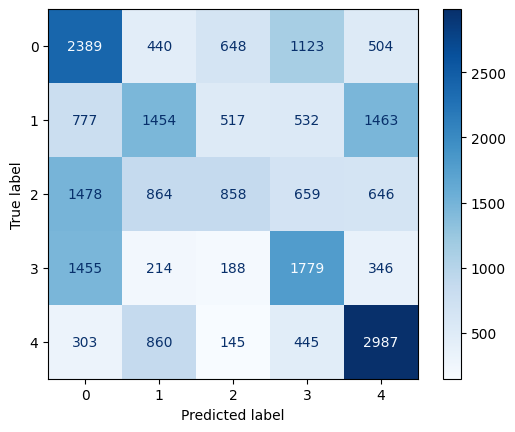

In [68]:
y_pred = final_model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_test))
disp.plot(cmap="Blues")
